In [1]:
%matplotlib inline
from ultralytics import YOLO
import os
from IPython.display import Image, display
import cv2
import matplotlib.pyplot as plt
print("Текущая рабочая директория:", os.getcwd())

Текущая рабочая директория: /home/a.pozdnyakov/AI-labs/laba3


In [2]:
model = YOLO('yolov5s.pt')

results = model.train(
    data='dataset/HRPlanes_v8/data.yaml',
    epochs=50,
    imgsz=640,
    batch=32,
    optimizer='SGD',
    cos_lr=True,
    device=0,
    workers=8,
    patience=20, # остановка
    plots=True,
    project='/home/a.pozdnyakov/AI-labs/laba3/runs',
    name='exp1',
    exist_ok=True,
    val=True,
    mosaic=0.8,
    mixup=0.1,
    copy_paste=0.1
)

PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

New https://pypi.org/project/ultralytics/8.4.47 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.46 🚀 Python-3.10.12 torch-2.10.0+cu128 CUDA:0 (Tesla V100-SXM2-32GB, 32494MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=dataset/HRPlanes_v8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=


results.png:


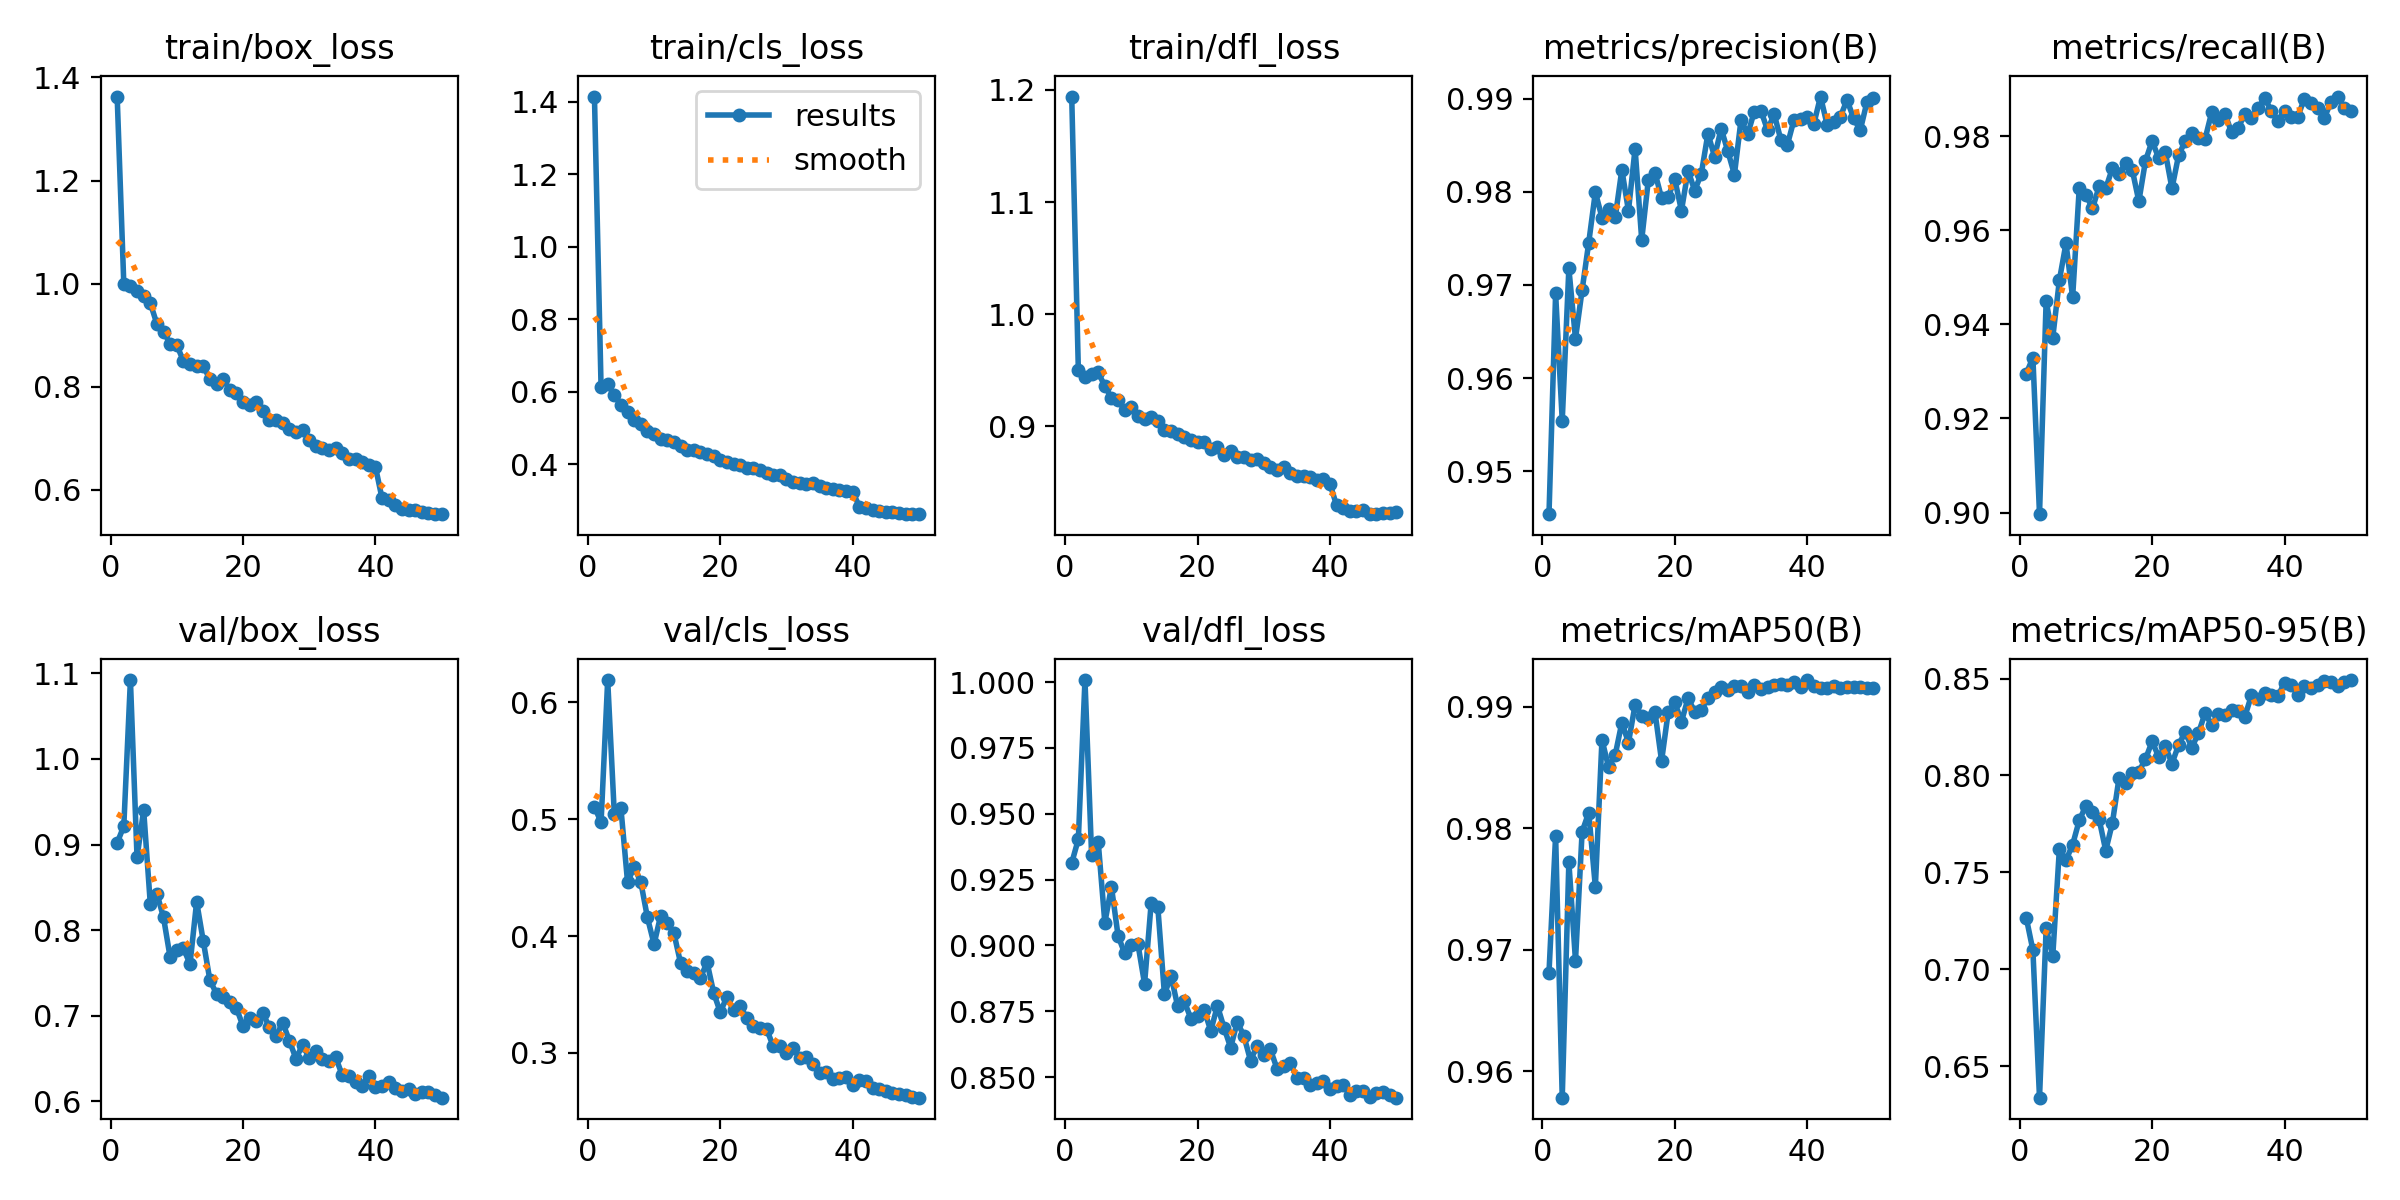


confusion_matrix.png:


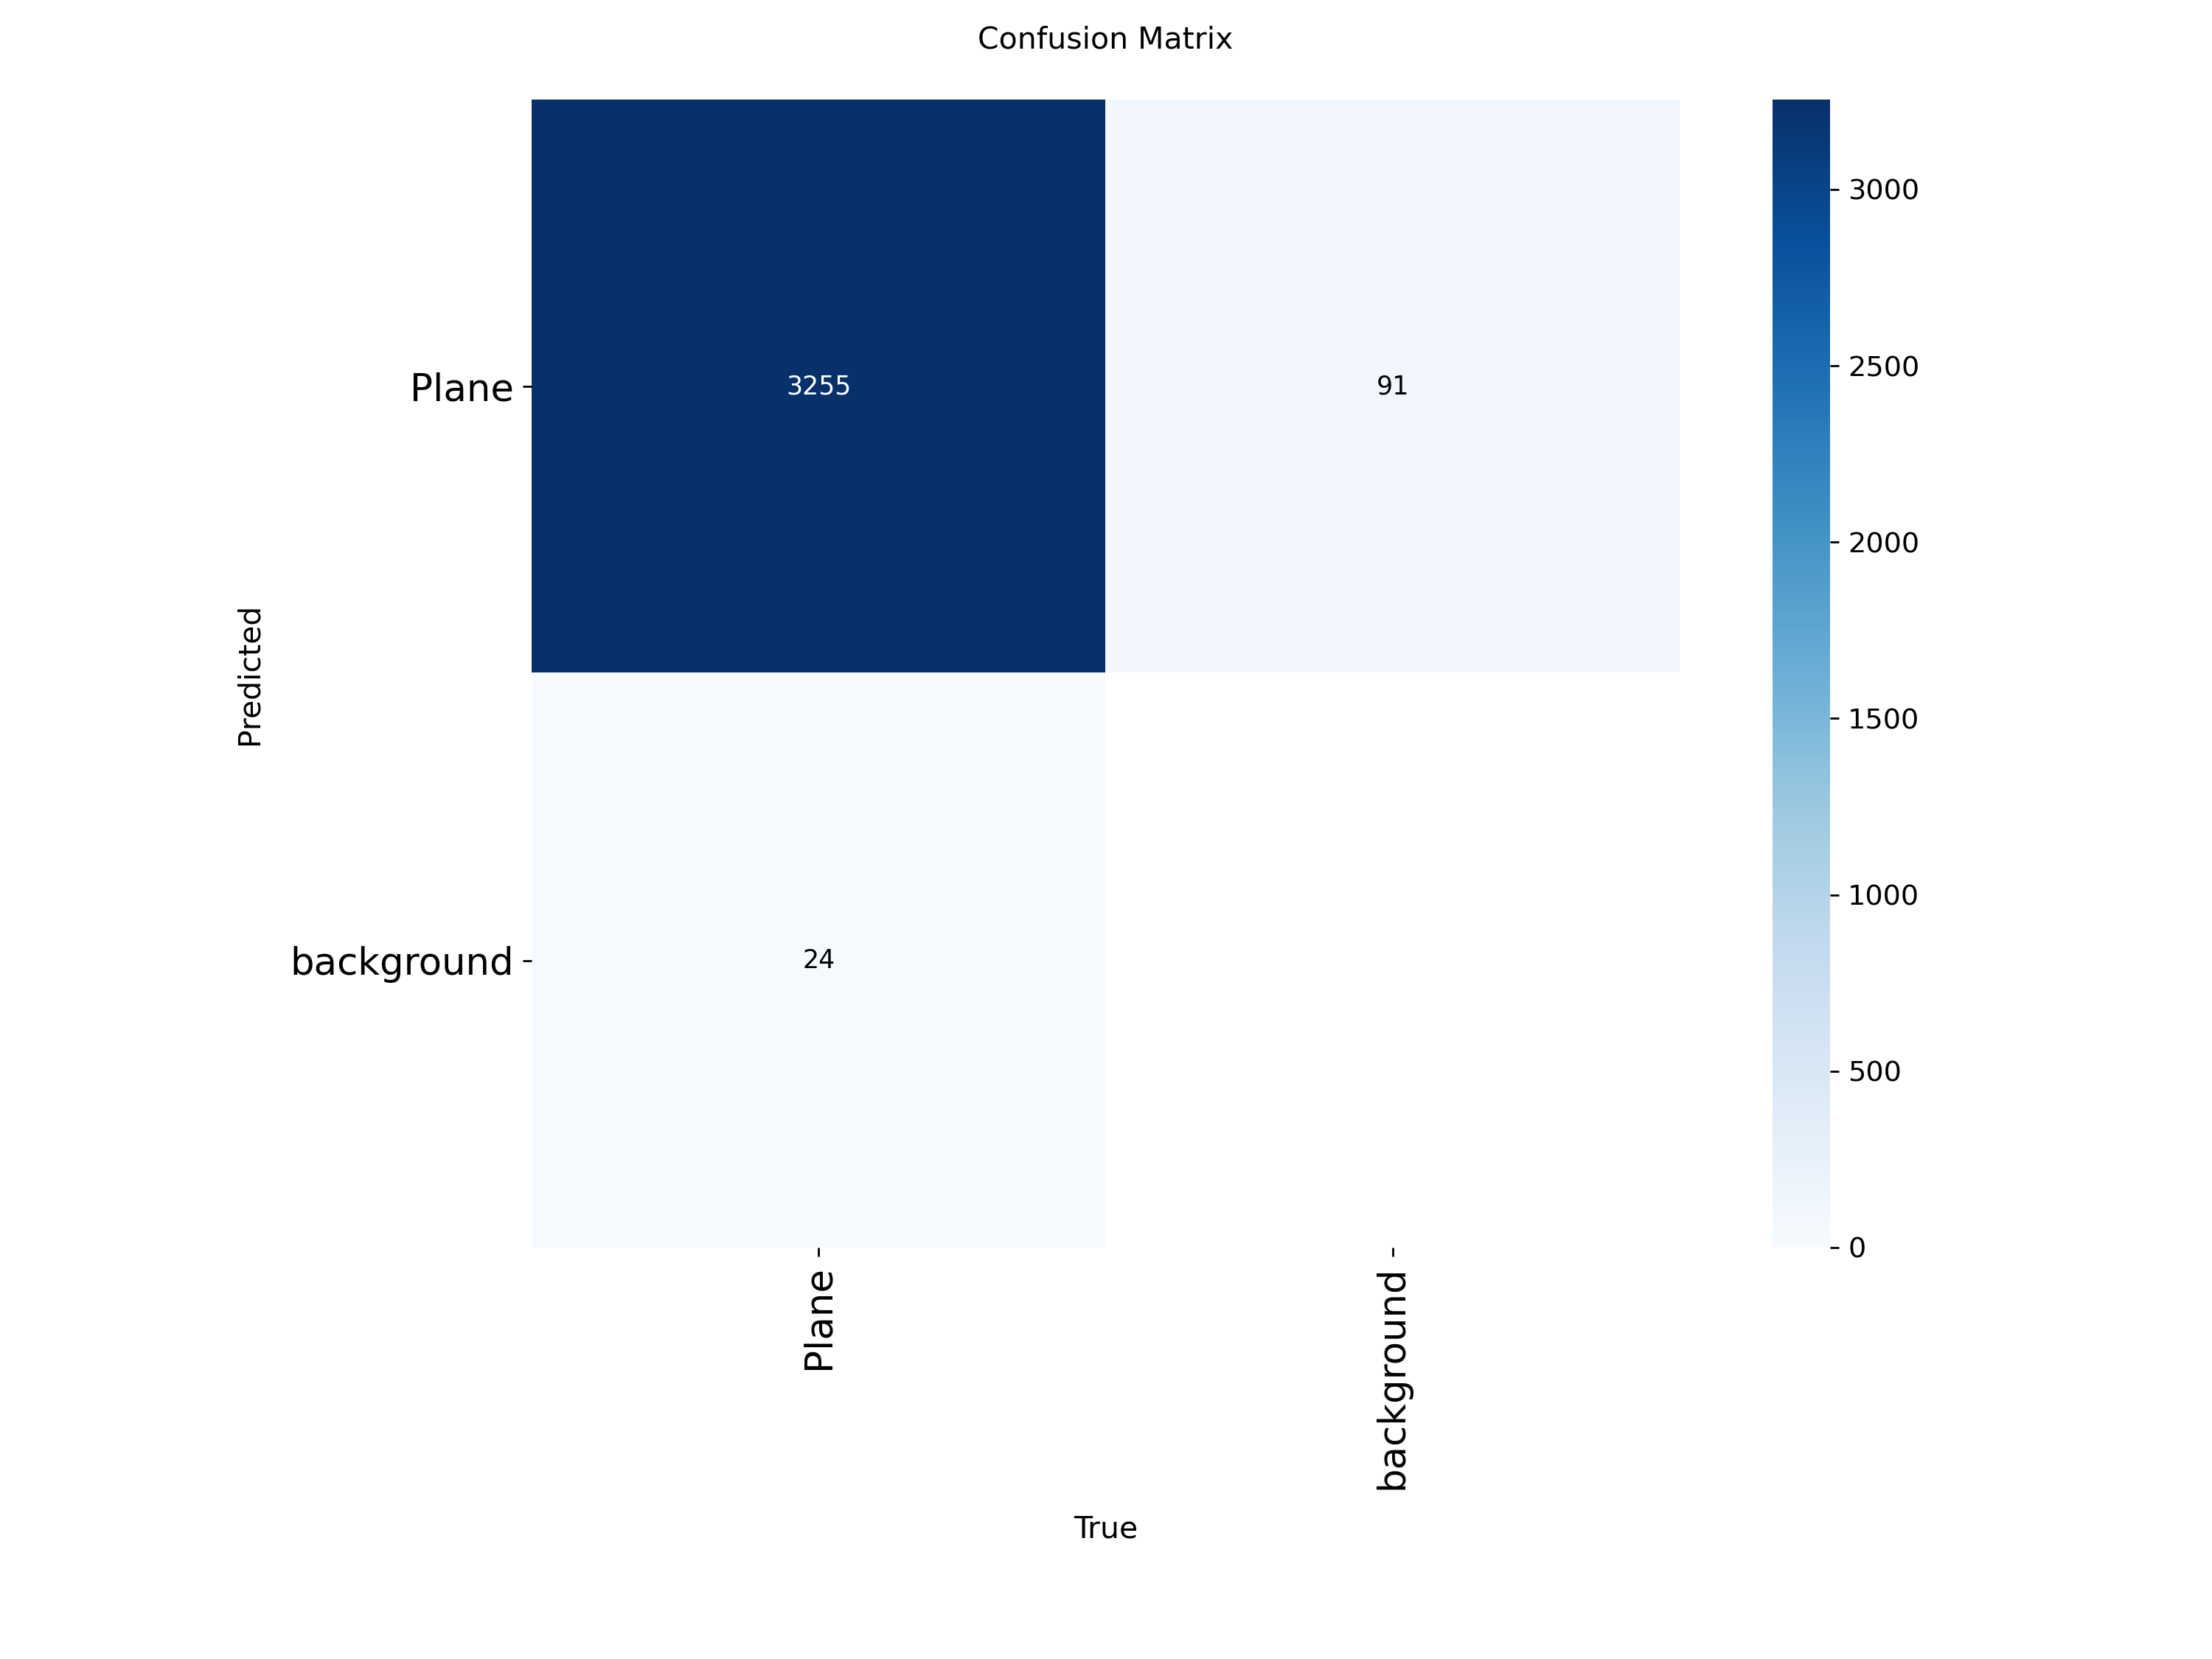


BoxPR_curve.png:


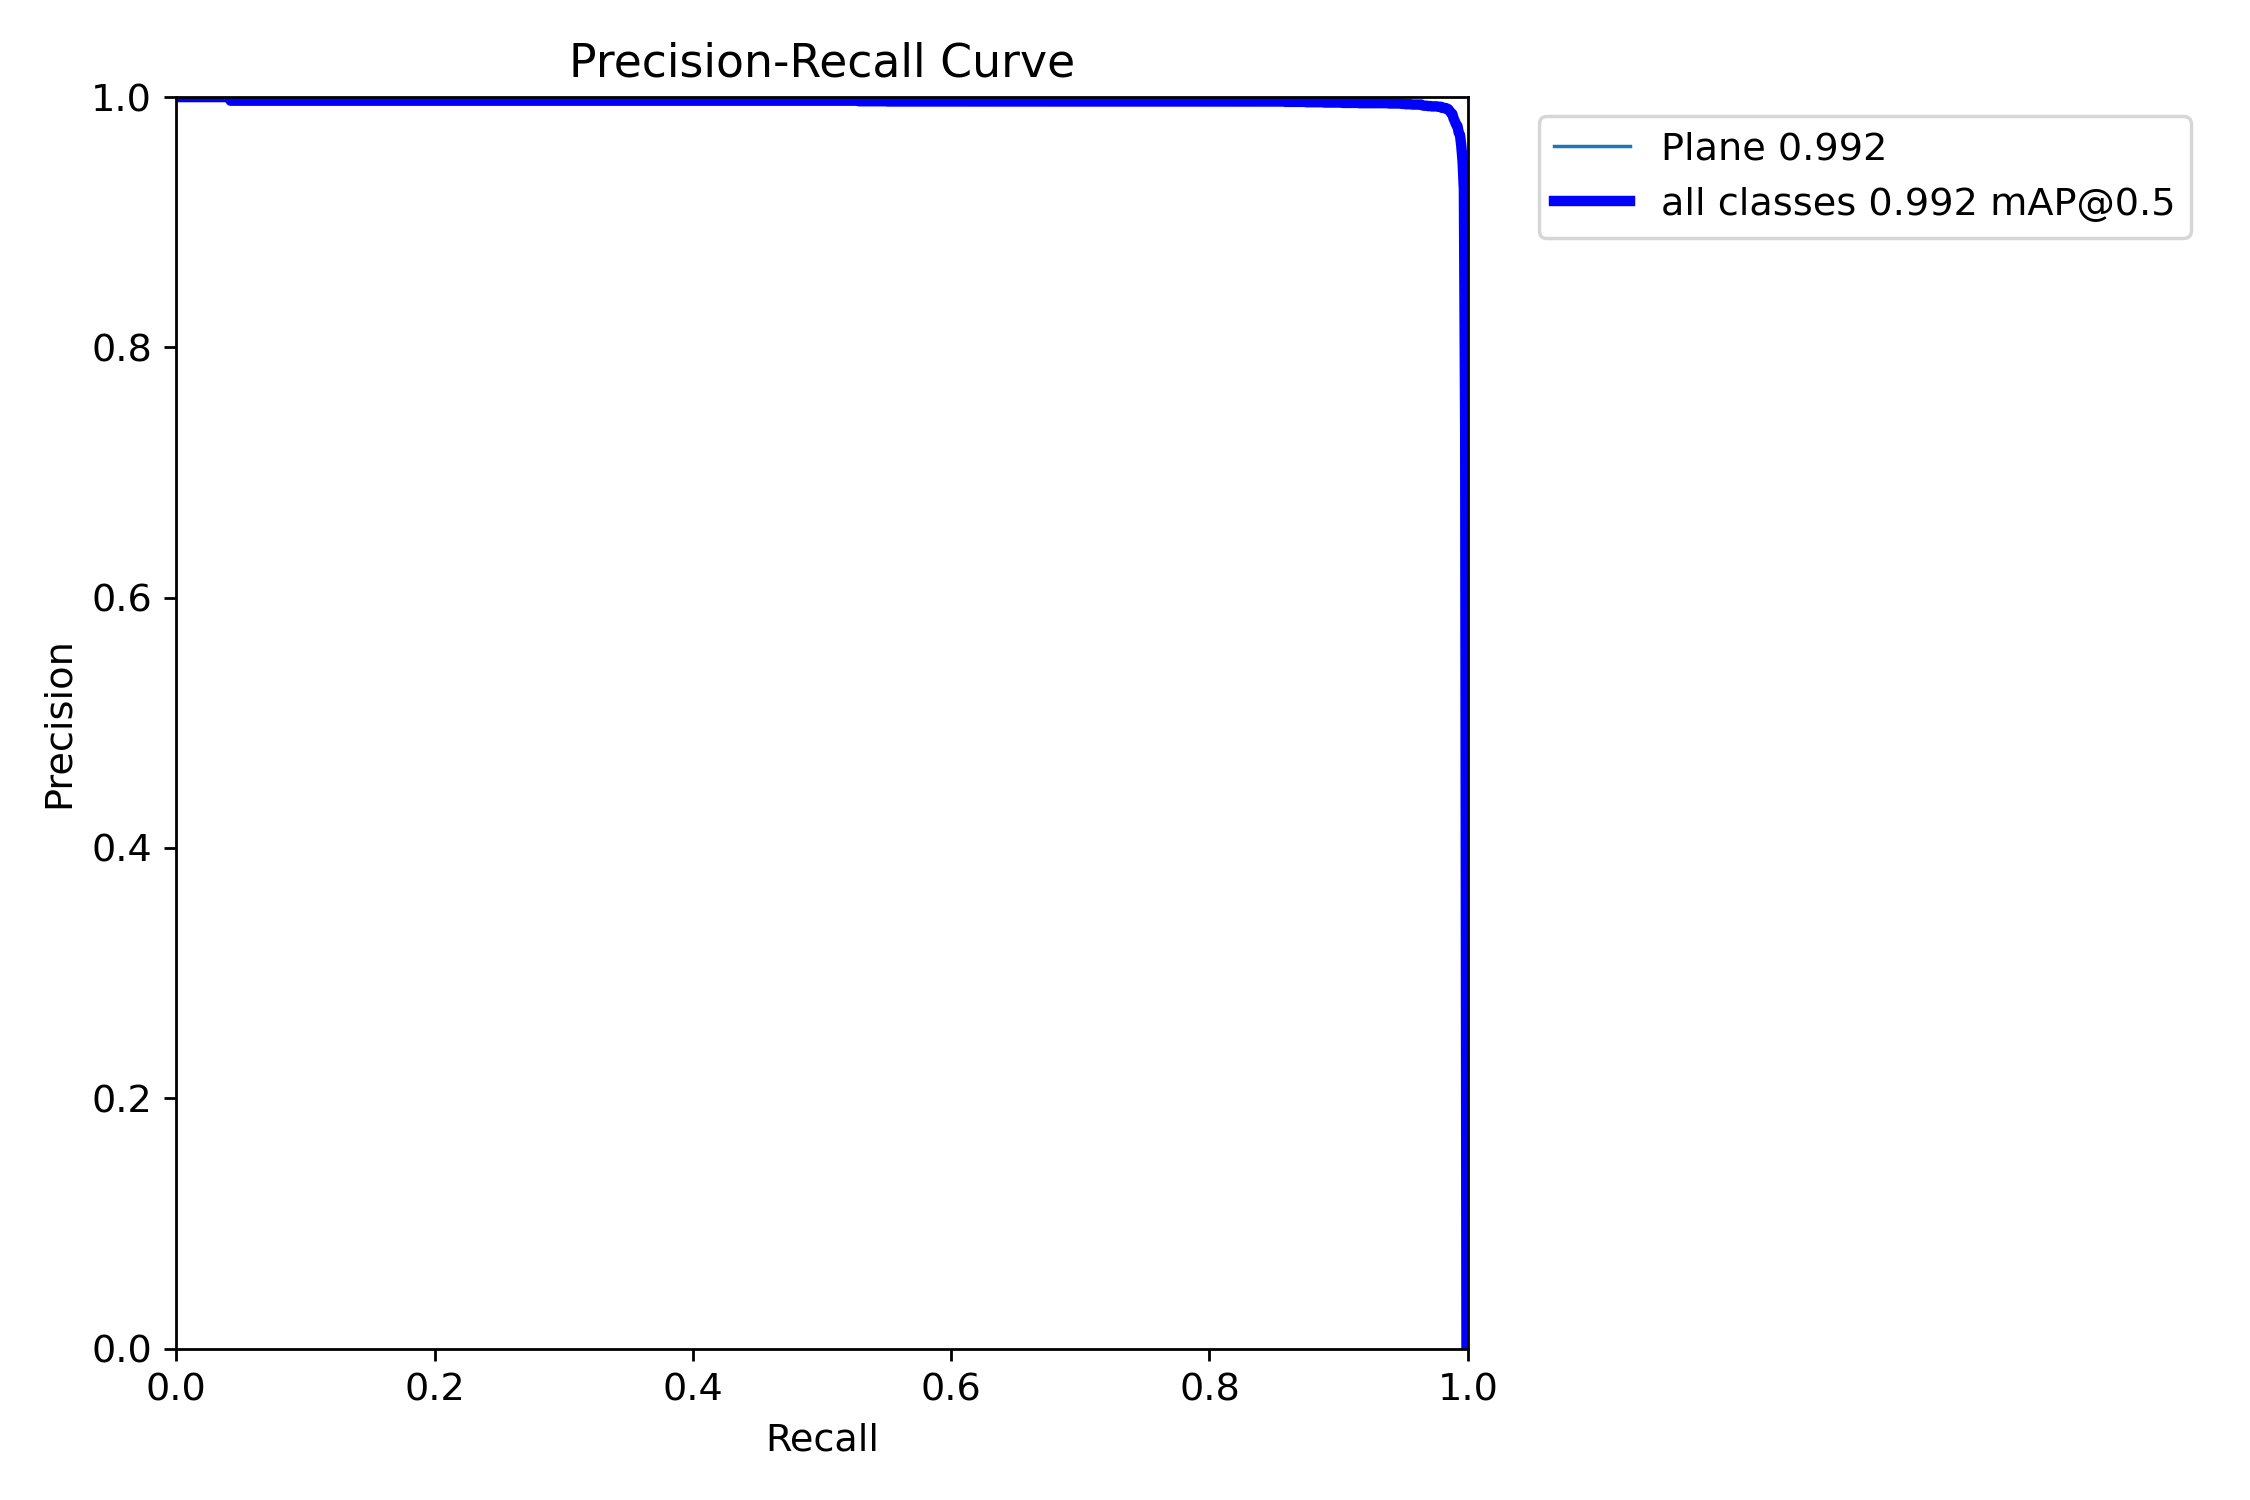


BoxF1_curve.png:


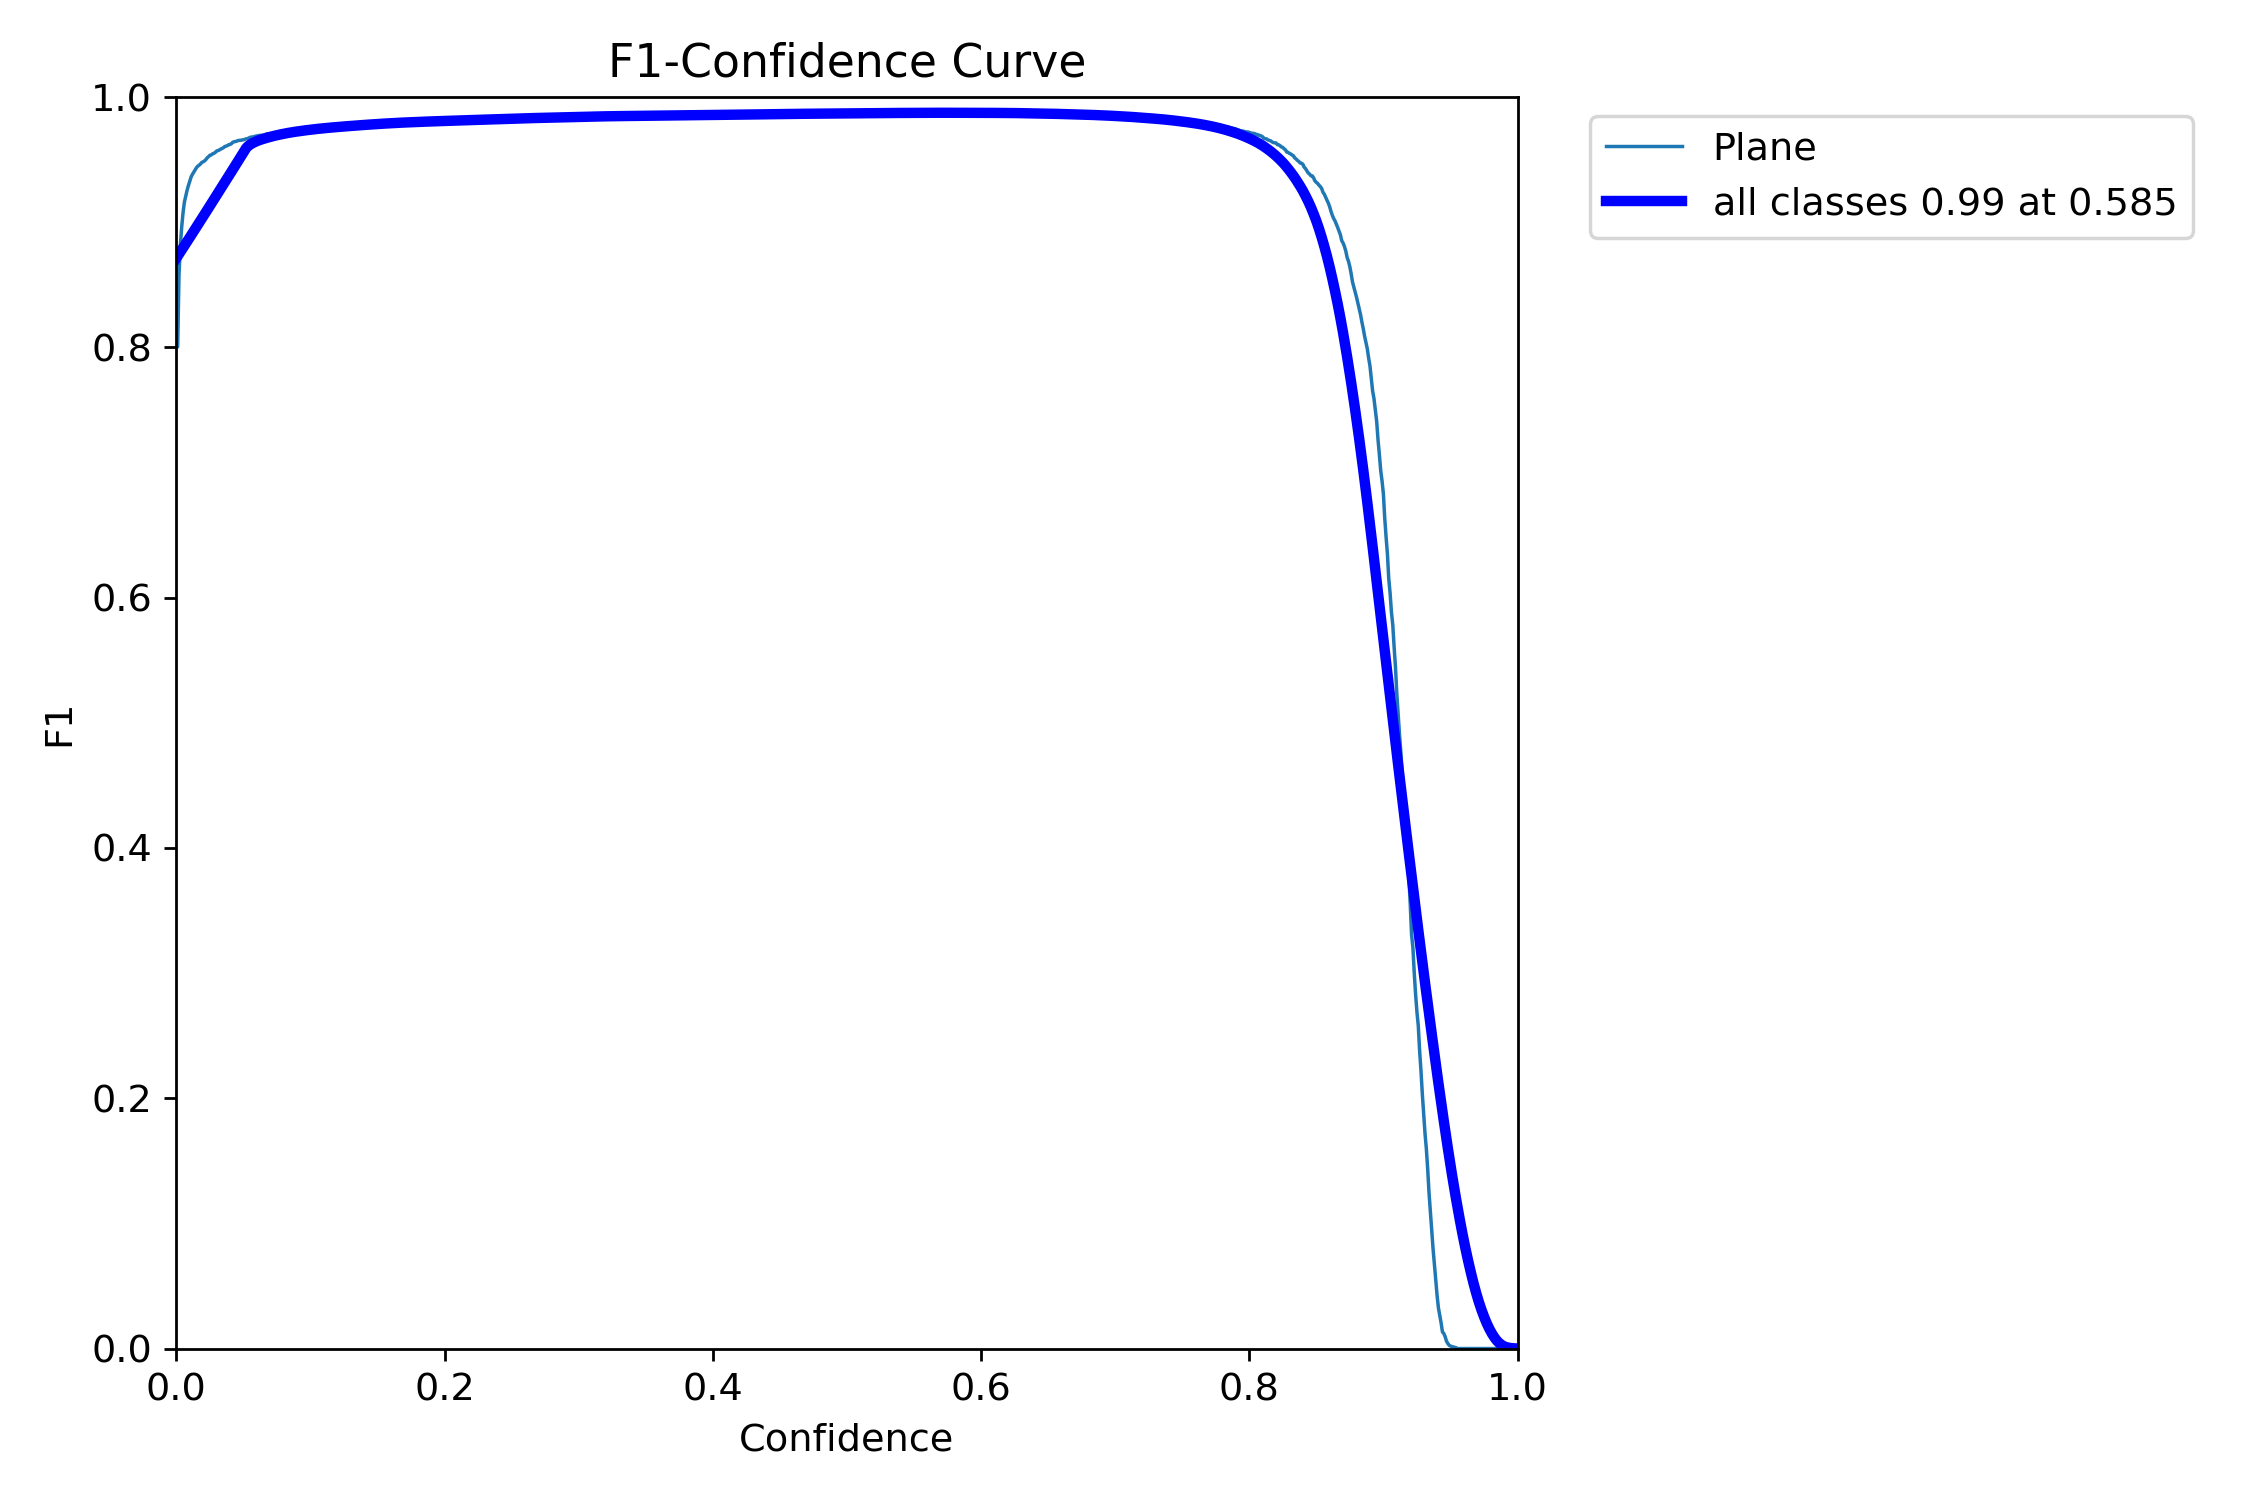

In [3]:
run_dir = '/home/a.pozdnyakov/AI-labs/laba3/runs/exp1'

plots = ['results.png', 'confusion_matrix.png', 'BoxPR_curve.png', 'BoxF1_curve.png']
for plot in plots:
    path = os.path.join(run_dir, plot)
    if os.path.exists(path):
        print(f"\n{plot}:")
        display(Image(path))
    else:
        print(f"{plot} не найден (возможно, обучение не завершилось или plots=False)")

In [4]:
best_model_path = os.path.join(run_dir, 'weights', 'best.pt')
best_model = YOLO(best_model_path)
metrics = best_model.val(split='test', plots=True)

print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision:{metrics.box.mp:.4f}")
print(f"Recall:   {metrics.box.mr:.4f}")

Ultralytics 8.4.46 🚀 Python-3.10.12 torch-2.10.0+cu128 CUDA:0 (Tesla V100-SXM2-32GB, 32494MiB)
YOLOv5s summary (fused): 85 layers, 9,111,923 parameters, 0 gradients, 23.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3732.6±601.7 MB/s, size: 2781.5 KB)
val: Scanning /home/a.pozdnyakov/AI-labs/laba3/dataset/HRPlanes_v8/labels/test.cache... 310 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 310/310 59.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 3.9it/s 5.1s0.2s
                   all        310       1924      0.989       0.98      0.993      0.849
Speed: 0.7ms preprocess, 2.3ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /home/a.pozdnyakov/AI-labs/runs/detect/val-3
mAP50:    0.9935
mAP50-95: 0.8495
Precision:0.9890
Recall:   0.9804



0: 384x640 2 Planes, 22.0ms
1: 384x640 3 Planes, 22.0ms
Speed: 2.7ms preprocess, 22.0ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


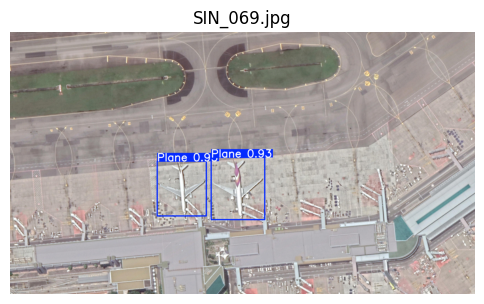

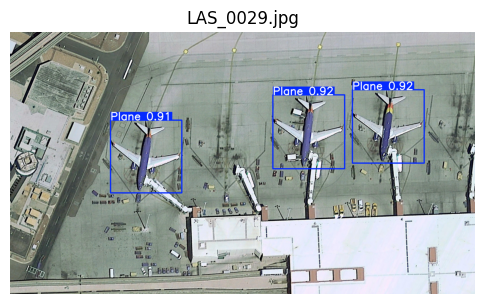

In [5]:
imgs = ['dataset/HRPlanes_v8/images/val/SIN_069.jpg', 'dataset/HRPlanes_v8/images/val/LAS_0029.jpg']

results = model.predict(imgs, conf=0.25, iou=0.45)

for res, path in zip(results, imgs):
    img_bgr = res.plot()
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    plt.title(os.path.basename(path))
    plt.axis('off')
    # plt.show()